In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully")

Matplotlib is building the font cache; this may take a moment.


Libraries loaded successfully


In [2]:
sales = pd.read_csv('../data/sales_train_evaluation.csv')
calendar = pd.read_csv('../data/calendar.csv')
prices = pd.read_csv('../data/sell_prices.csv')

print("Sales shape:", sales.shape)
print("Calendar shape:", calendar.shape)
print("Prices shape:", prices.shape)

Sales shape: (30490, 1947)
Calendar shape: (1969, 14)
Prices shape: (6841121, 4)


In [3]:
sales.head(3)

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1


In [4]:
print("First 10 columns:", sales.columns[:10].tolist())
print("Last 5 columns:", sales.columns[-5:].tolist())
print("\nUnique states:", sales['state_id'].unique())
print("Unique categories:", sales['cat_id'].unique())

First 10 columns: ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2', 'd_3', 'd_4']
Last 5 columns: ['d_1937', 'd_1938', 'd_1939', 'd_1940', 'd_1941']

Unique states: ['CA' 'TX' 'WI']
Unique categories: ['HOBBIES' 'HOUSEHOLD' 'FOODS']


In [5]:
calendar.head(5)

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [6]:
day_cols = [c for c in sales.columns if c.startswith('d_')]
sales['total_sales'] = sales[day_cols].sum(axis=1)

top_items = (
    sales[sales['state_id'] == 'CA']
    .groupby('item_id')['total_sales']
    .sum()
    .nlargest(50)
    .index
)

subset = sales[
    (sales['state_id'] == 'CA') &
    (sales['item_id'].isin(top_items))
].copy()

subset.drop(columns=['total_sales'], inplace=True)

print(f"Subset shape: {subset.shape}")
print(f"Unique items: {subset['item_id'].nunique()}")
print(f"Unique stores: {subset['store_id'].nunique()}")

Subset shape: (200, 1947)
Unique items: 50
Unique stores: 4


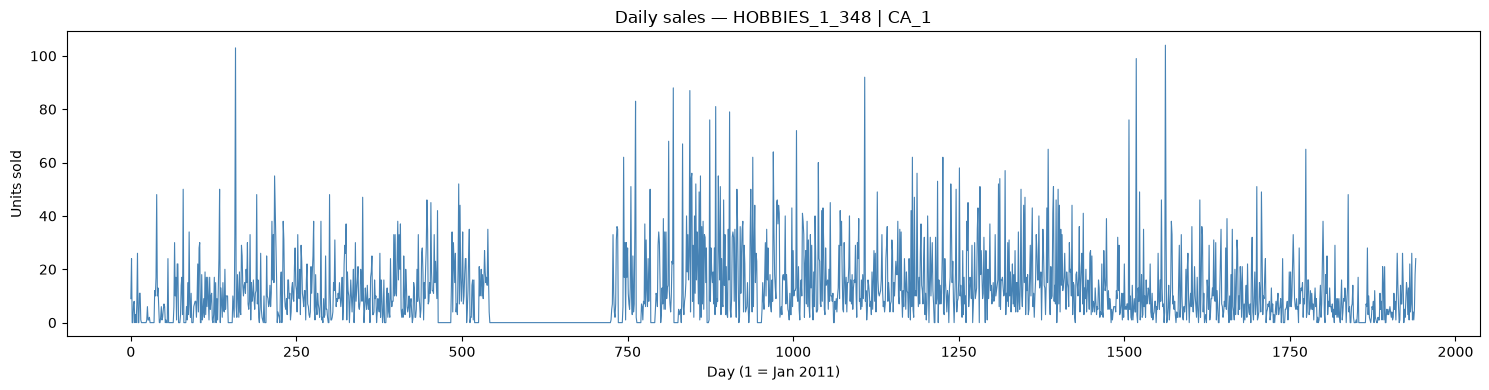


Total days of data: 1941
Average daily sales: 11.85
Zero sale days: 400 (20.6%)


In [7]:

item_row = subset.iloc[0]
sales_values = item_row[day_cols].values.astype(float)

plt.figure(figsize=(15, 4))
plt.plot(sales_values, linewidth=0.8, color='steelblue')
plt.title(f"Daily sales — {item_row['item_id']} | {item_row['store_id']}")
plt.xlabel("Day (1 = Jan 2011)")
plt.ylabel("Units sold")
plt.tight_layout()
plt.show()

print(f"\nTotal days of data: {len(sales_values)}")
print(f"Average daily sales: {sales_values.mean():.2f}")
print(f"Zero sale days: {(sales_values == 0).sum()} ({(sales_values == 0).mean()*100:.1f}%)")

In [8]:

subset.to_csv('../data/subset.csv', index=False)
print("Saved subset.csv — this is your working dataset for the whole project")

Saved subset.csv — this is your working dataset for the whole project


In [9]:
git add notebooks/ requirements.txt .gitignore src/ dashboard/ docker/
git commit -m "Day 1: project setup, M5 data loaded, CA subset saved"
git push origin main

SyntaxError: invalid syntax (3591749637.py, line 1)